In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer, losses, InputExample
from sentence_transformers.sentence_transformer.losses import CosineSimilarityLoss
from sentence_transformers.sentence_transformer.evaluation import EmbeddingSimilarityEvaluator
from torch.utils.data import DataLoader
from datasets import Dataset


from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report



import warnings
import json

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

/var/folders/l_/hkf27kv97fj8jk_nbph32jfm0000gn/T/ipykernel_34963/2972808839.py:6: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, losses, InputExample


In [2]:
df = pd.read_csv("cleaned_resumeJD_pairs.csv")
df.head(2)

,resume_text,job_description,match_label,match_score,match_label_lower,resume_len,jd_len
0,BI Analyst with 7 years of experience based in...,Fathom is hiring a Financial Analyst (Berlin)....,medium,0.53,medium,75,71
1,Data Scientist with 13 years of experience bas...,Lumen is hiring a Senior UX Designer (Singapor...,low,0.26,low,79,74


In [3]:
train_df , temp_df = train_test_split(
    df, test_size= 0.3 , random_state=42 , stratify=df['match_label']
)

val_df , test_df = train_test_split(
    temp_df , test_size=0.5 , random_state=42 , stratify=temp_df['match_label']
)

print(f'Train : {len(train_df)} pairs')
print(f'Validation : {len(val_df)}pairs' )
print(f'Test : {len(test_df)} pairs' )

Train : 196 pairs
Validation : 42pairs
Test : 42 pairs


### Convert to InputExample formaat - sentence-transformers expects this 
### text1 = resume , text2 = job description , label = match_score (float 0-1)

In [4]:
from sentence_transformers import InputExample

train_examples = [
    InputExample(
        texts=[row['resume_text'], row['job_description']],
        label=float(row['match_score'])
    )
    for _, row in train_df.iterrows()
]

val_examples = [
    InputExample(
        texts=[row['resume_text'], row['job_description']],
        label=float(row['match_score'])
    )
    for _, row in val_df.iterrows()
]

print(f' train example : {len(train_examples)}')
print(f' val example : {len(val_examples)}')

 train example : 196
 val example : 42


In [5]:
base_model = SentenceTransformer('all-mpnet-base-v2')
print("model loaded...")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model loaded...


In [6]:
base_preds = []

for _, row in test_df.iterrows():

    emb1 = base_model.encode(row['resume_text'])
    emb2 = base_model.encode(row['job_description'])

    sim = cosine_similarity([emb1], [emb2])[0][0]

    base_preds.append(float(sim))


# Calculate metrics
base_mae = mean_absolute_error(
    test_df['match_score'],
    base_preds
)

base_rmse = np.sqrt(
    mean_squared_error(
        test_df['match_score'],
        base_preds
    )
)


print('\nBase Model - Test Set')

print(f'MAE  : {base_mae:.4f}')
print(f'RMSE : {base_rmse:.4f}')

print("Goal fine tuning should reduce MAE below this number")



Base Model - Test Set
MAE  : 0.1946
RMSE : 0.2332
Goal fine tuning should reduce MAE below this number


In [7]:
from sentence_transformers import SentenceTransformer, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from torch.utils.data import DataLoader

model = SentenceTransformer('all-mpnet-base-v2')

train_dataloader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=16
)

train_loss = CosineSimilarityLoss(model)

evaluator = EmbeddingSimilarityEvaluator.from_input_examples(
    val_examples,
    name='ats-val'
)

print(f'Train pairs : {len(train_examples)}')
print(f'Steps/epoch : {len(train_dataloader)}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Train pairs : 196
Steps/epoch : 13


In [8]:
total_steps = len(train_dataloader) * 10
warmup_steps = int(total_steps * 0.1)

print(f'Total steps: {total_steps}')
print(f'Warmup steps: {warmup_steps}')
print(f'\nStarting fine-tuning...\n')

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=10,
    evaluation_steps=len(train_dataloader),
    warmup_steps=warmup_steps,
    output_path='models/finetuned-mpnet',
    save_best_model=True,
    show_progress_bar=True
)

Total steps: 130
Warmup steps: 13

Starting fine-tuning...



Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Ats-val Pearson Cosine,Ats-val Spearman Cosine
13,No log,No log,0.720277,0.706588
26,No log,No log,0.737671,0.726779
39,No log,No log,0.741802,0.722157
52,No log,No log,0.746621,0.729779
65,No log,No log,0.753591,0.745834
78,No log,No log,0.767933,0.757186
91,No log,No log,0.774449,0.766674
104,No log,No log,0.774967,0.766836
117,No log,No log,0.771321,0.758808
130,No log,No log,0.771351,0.758808


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
finetuned_model = SentenceTransformer('models/finetuned-mpnet')
print("Fine-tuned model loaded")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned model loaded


In [10]:
ft_preds = []

for _, row in test_df.iterrows():

    emb1 = finetuned_model.encode(row['resume_text'])
    emb2 = finetuned_model.encode(row['job_description'])

    sim = cosine_similarity([emb1], [emb2])[0][0]

    ft_preds.append(float(sim))


ft_mae = mean_absolute_error(
    test_df['match_score'],
    ft_preds
)

ft_rmse = np.sqrt(
    mean_squared_error(
        test_df['match_score'],
        ft_preds
    )
)


print('\nFine-tuned Model - Test Set Performance')
print(f'  MAE : {ft_mae:.4f}')
print(f'  RMSE: {ft_rmse:.4f}')


Fine-tuned Model - Test Set Performance
  MAE : 0.1014
  RMSE: 0.1247


In [11]:
# Side-by-side comparison

print('=' * 50)
print('MODEL COMPARISON')
print('=' * 50)

print(f'  Base MAE:        {base_mae:.4f}')
print(f'  Fine-tuned MAE:  {ft_mae:.4f}')

improvement = ((base_mae - ft_mae) / base_mae) * 100

print(f'  Improvement:     {improvement:.1f}%')
print('=' * 50)

MODEL COMPARISON
  Base MAE:        0.1946
  Fine-tuned MAE:  0.1014
  Improvement:     47.9%


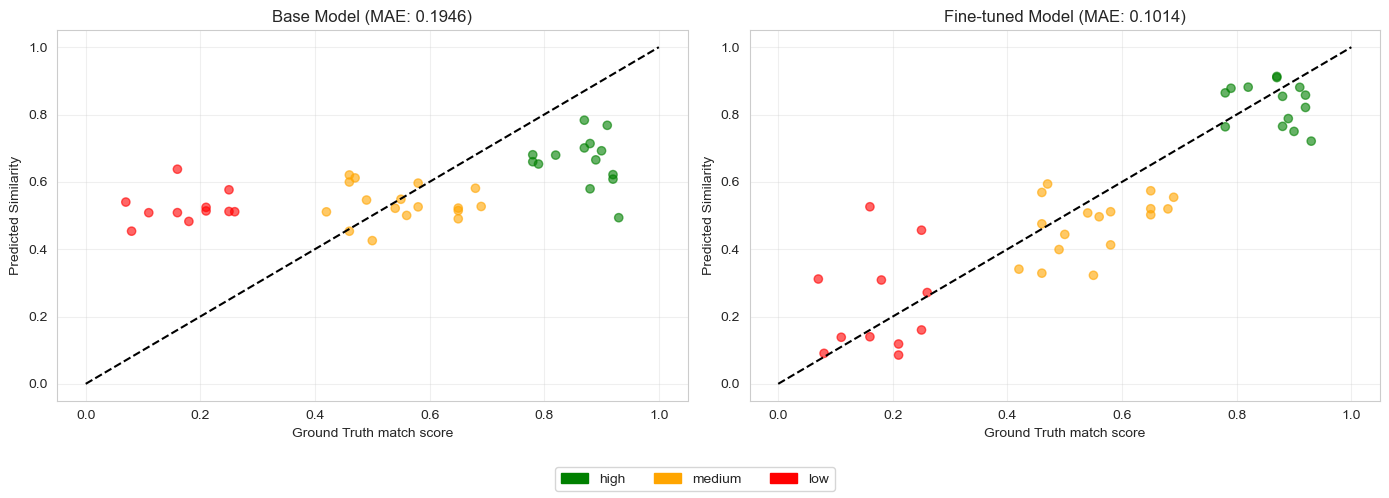

In [12]:
# Scatter plots: base vs fine-tuned

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = test_df['match_label'].map({
    'high': 'green',
    'medium': 'orange',
    'low': 'red'
})

for ax, preds, title, mae in [
    (axes[0], base_preds, 'Base Model', base_mae),
    (axes[1], ft_preds, 'Fine-tuned Model', ft_mae)
]:
    ax.scatter(
        test_df['match_score'],
        preds,
        c=colors,
        alpha=0.6
    )

    ax.plot(
        [0, 1],
        [0, 1],
        'k--',
        label='Perfect prediction'
    )

    ax.set_xlabel('Ground Truth match score')
    ax.set_ylabel('Predicted Similarity')
    ax.set_title(f'{title} (MAE: {mae:.4f})')
    ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch

fig.legend(
    handles=[
        Patch(color='green', label='high'),
        Patch(color='orange', label='medium'),
        Patch(color='red', label='low')
    ],
    loc='lower center',
    ncol=3
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [13]:
metadata = {
    'base_model': 'all-mpnet-base-v2',
    'dataset': 'merged_dataset_clean.csv',
    'total_pairs': len(df),
    'train_pairs': len(train_df),
    'val_pairs': len(val_df),
    'test_pairs': len(test_df),
    'epochs': 10,
    'batch_size': 16,
    'base_mae': round(float(base_mae), 4),
    'finetuned_mae': round(float(ft_mae), 4),
    'improvement_pct': round(
        ((base_mae - ft_mae) / base_mae) * 100, 2
    )
}

with open('models/finetuned-mpnet/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: models/finetuned-mpnet/metadata.json')
print(json.dumps(metadata, indent=2))

Saved: models/finetuned-mpnet/metadata.json
{
  "base_model": "all-mpnet-base-v2",
  "dataset": "merged_dataset_clean.csv",
  "total_pairs": 280,
  "train_pairs": 196,
  "val_pairs": 42,
  "test_pairs": 42,
  "epochs": 10,
  "batch_size": 16,
  "base_mae": 0.1946,
  "finetuned_mae": 0.1014,
  "improvement_pct": 47.89
}


In [14]:
# Production Pipeline Test

def score_resume_against_jd(resume_text, jd_text, model):
    emb_resume = model.encode(
        resume_text,
        convert_to_numpy=True
    )

    emb_jd = model.encode(
        jd_text,
        convert_to_numpy=True
    )

    score = cosine_similarity(
        [emb_resume],
        [emb_jd]
    )[0][0]

    return float(score)


# Test with realistic cases
test_cases = [
    {
        'label': 'HIGH match expected',
        'resume': 'Senior Python developer with 6 years experience in Python, FastAPI, Django, REST APIs, PostgreSQL and backend development.',
        'jd': 'We need a Python backend engineer with FastAPI, Django, REST API and PostgreSQL experience.'
    },
    {
        'label': 'MEDIUM match expected',
        'resume': 'Frontend developer with 3 years React, JavaScript, HTML and CSS experience.',
        'jd': 'Full stack engineer needed. React frontend experience and some backend development with Python.'
    },
    {
        'label': 'LOW match expected',
        'resume': 'Executive Chef with 12 years experience in restaurants, food preparation and kitchen management.',
        'jd': 'Data Scientist with Python, machine learning, pandas, NumPy and scikit-learn experience.'
    }
]


print('=' * 60)
print('PRODUCTION PIPELINE TEST')
print('=' * 60)

for case in test_cases:
    score = score_resume_against_jd(
        case['resume'],
        case['jd'],
        model
    )

    print(f"\n{case['label']}")
    print(f"Similarity Score: {score:.4f}")
    print(f"Similarity: {score * 100:.2f}%")

print('\n' + '=' * 60)

PRODUCTION PIPELINE TEST

HIGH match expected
Similarity Score: 0.8941
Similarity: 89.41%

MEDIUM match expected
Similarity Score: 0.8073
Similarity: 80.73%

LOW match expected
Similarity Score: 0.2019
Similarity: 20.19%

